# Heart Disease Prediction using Machine Learning

## Model Comparison (JSON-Based)

### Objective
This notebook compares the final saved results of:
- Logistic Regression
- Random Forest

The metrics are loaded directly from:
- `comparison/logistic.json`
- `comparison/random_forest.json`

### Metrics Used
- Threshold
- Accuracy
- Precision
- Recall
- F1
- AUC

This notebook does **not** retrain models. It only compares exported results for clarity and consistency.

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
with open("logistic.json", "r") as f:
    log_res = json.load(f)

with open("random_forest.json", "r") as f:
    rf_res = json.load(f)

In [8]:
# Compare saved metrics from JSON files
required_keys = {"model", "threshold", "accuracy", "precision", "recall", "f1", "auc"}
for file_name, metrics_dict in [("logistic.json", log_res), ("random_forest.json", rf_res)]:
    missing = required_keys - set(metrics_dict.keys())
    if missing:
        raise ValueError(f"{file_name} is missing keys: {sorted(missing)}")

json_results_df = pd.DataFrame([
    {
        "Model": log_res["model"],
        "Threshold": log_res["threshold"],
        "Accuracy": log_res["accuracy"],
        "Precision": log_res["precision"],
        "Recall": log_res["recall"],
        "F1": log_res["f1"],
        "AUC": log_res["auc"],
    },
    {
        "Model": rf_res["model"],
        "Threshold": rf_res["threshold"],
        "Accuracy": rf_res["accuracy"],
        "Precision": rf_res["precision"],
        "Recall": rf_res["recall"],
        "F1": rf_res["f1"],
        "AUC": rf_res["auc"],
    },
])[ ["Model", "Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"] ].round(4)

json_results_df

,Model,Threshold,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.35,0.8696,0.8609,0.9252,0.8919,0.9239
1,Random Forest,0.35,0.8804,0.8632,0.9439,0.9018,0.9383


## Interpretation Guide

- **Accuracy**: overall correctness
- **Precision**: how many predicted positives are truly positive
- **Recall**: how many actual positives are correctly detected
- **F1**: balance between precision and recall
- **AUC**: overall ranking quality across thresholds

For heart disease screening, prioritize **Recall** and **F1**.

Best model by metric:
- Accuracy: Random Forest
- Precision: Random Forest
- Recall: Random Forest
- F1: Random Forest
- AUC: Random Forest

Recommended for screening (high recall priority): Random Forest


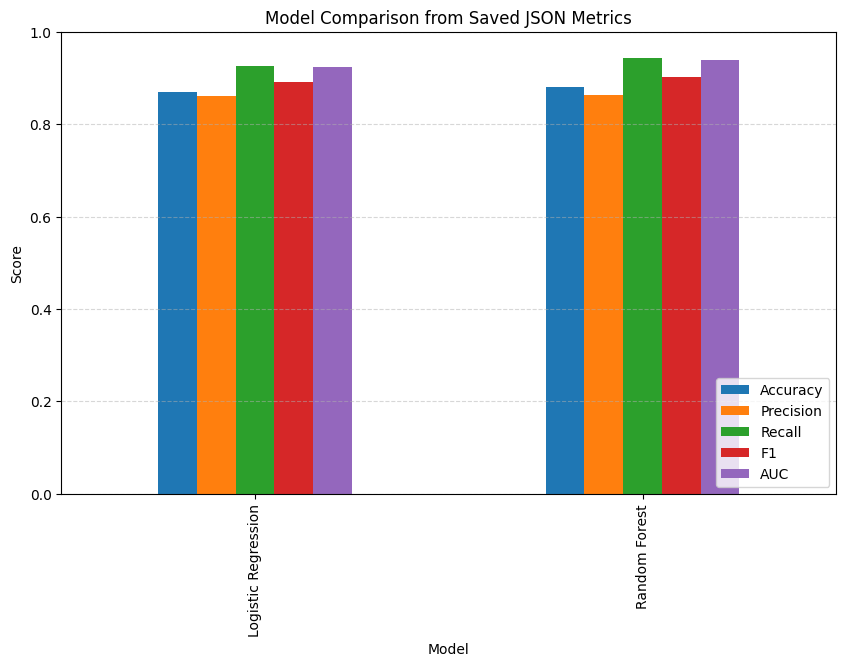

In [9]:
# Rank and visualize model performance clearly
plot_json_df = json_results_df.set_index("Model")

# Leader by each metric
leaders = {
    "Accuracy": plot_json_df["Accuracy"].idxmax(),
    "Precision": plot_json_df["Precision"].idxmax(),
    "Recall": plot_json_df["Recall"].idxmax(),
    "F1": plot_json_df["F1"].idxmax(),
    "AUC": plot_json_df["AUC"].idxmax(),
}

print("Best model by metric:")
for metric, model_name in leaders.items():
    print(f"- {metric}: {model_name}")

# Recommended model for screening focus
recommended_model = leaders["Recall"]
print(f"\nRecommended for screening (high recall priority): {recommended_model}")

plot_json_df[["Accuracy", "Precision", "Recall", "F1", "AUC"]].plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison from Saved JSON Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.show()